## Thelia的手撕线性回归尝试！

### 随机生成一个数据集吧~

In [ ]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import time

n_samples = 50
seed = int(time.time())  # 每分钟更新一次随机种子，确保每次运行生成不同的样本
# 原函数参数 y = a * x + b
random.seed(seed)
a = random.uniform(-4, 4)
b = random.uniform(-10, 10)

# 方差与样本数（方差越大，点越分散）
noise_std = random.uniform(5, 10) * abs(a)
rng = np.random.default_rng(seed)
x = np.arange(1, n_samples + 1)
noise = rng.normal(0, noise_std, size=n_samples)
y = a * x + b + noise

df = pd.DataFrame({
    'x': x,
    'y': np.round(y, 1),
})

csv_path = Path('linear_regression_sample.csv')
df.to_csv(csv_path, index=False)
print(f'已生成 {n_samples} 条样本，保存到: {csv_path.resolve()}')
df.head()

已生成 50 条样本，保存到: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/linear_regression_sample.csv


,x,y
0,1,-19.7
1,2,-18.8
2,3,-12.5
3,4,10.8
4,5,21.9


### **第一步：导入包**

In [530]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **第二步：导入数据**

In [531]:
dataset = pd.read_csv('linear_regression_sample.csv')
print(dataset)
X = dataset.iloc[:, :-1].values #输入矩阵
y = dataset.iloc[:, -1].values #输出矩阵

     x      y
0    1  -19.7
1    2  -18.8
2    3  -12.5
3    4   10.8
4    5   21.9
5    6    9.5
6    7   41.1
7    8   11.1
8    9   45.3
9   10   26.8
10  11   29.2
11  12   17.2
12  13    0.8
13  14   60.4
14  15   21.2
15  16   12.7
16  17   24.1
17  18   78.6
18  19   72.1
19  20   17.3
20  21   50.9
21  22   45.6
22  23   54.9
23  24   56.7
24  25   47.5
25  26   31.0
26  27   41.5
27  28   86.4
28  29   18.4
29  30   57.8
30  31   74.9
31  32   65.0
32  33   92.9
33  34   78.3
34  35   90.8
35  36   88.1
36  37   99.1
37  38   92.8
38  39   89.9
39  40   80.7
40  41   76.6
41  42   80.8
42  43   97.2
43  44   82.0
44  45  127.3
45  46   99.8
46  47   90.9
47  48   87.6
48  49  143.0
49  50  103.7


#### 试着画个散点图？

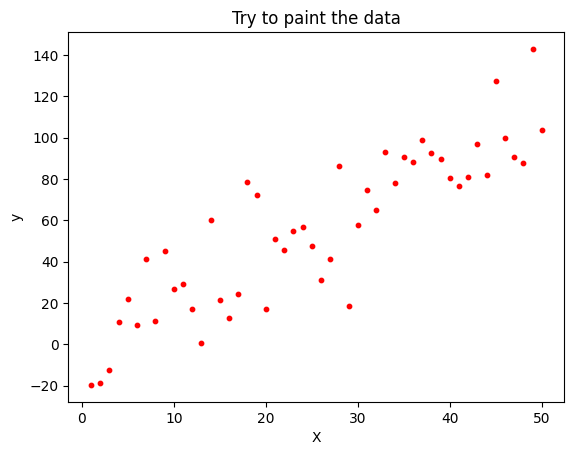

In [532]:
plt.scatter(X, y, color='red', s=10)
plt.title('Try to paint the data')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

### 区分一下训练数据和测试数据~

In [533]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

### 线性回归，启动！

In [534]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iters=30000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape #数据量&特征数
        # 初始化权重和偏置
        self.w = np.zeros(n_features)
        self.b = 0

        # 梯度下降
        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.w) + self.b
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.w) + self.b
        return linear_model
        

### 训练一下

In [535]:
LM = LinearRegression()
LM.fit(X_train, y_train)

### 看看结果

Learned parameters: w=2.3174, b=-2.6401
True parameters: a=2.0470, b=2.4795
Test MSE: 352.6920


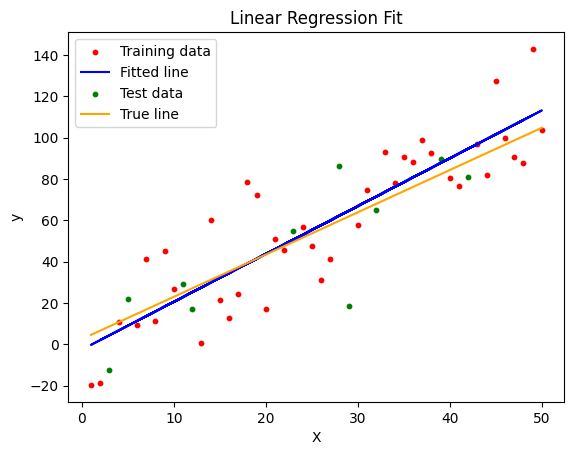

In [536]:
plt.scatter(X_train, y_train, color='red', s=10, label='Training data')
plt.plot(X_train, LM.predict(X_train), color='blue', label='Fitted line')
plt.scatter(X_test, y_test, color='green', s=10, label='Test data')
plt.plot(X, a * X + b, color='orange', label='True line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Training data','Fitted line','Test data','True line'])
print(f'Learned parameters: w={LM.w[0]:.4f}, b={LM.b:.4f}')
print(f'True parameters: a={a:.4f}, b={b:.4f}')
print(f'Test MSE: {np.mean((LM.predict(X_test) - y_test) ** 2):.4f}')